In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("train.csv")

In [2]:
print(train.dtypes)
print("\nMissing values:\n", train.isnull().sum()[train.isnull().sum() > 0])
print("\nNumeric summary:\n", train.describe())

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_delivered_customer_date        str
order_estimated_delivery_date        str
num_items                        float64
total_price                      float64
total_freight                    float64
seller_id                            str
num_unique_sellers               float64
seller_state                         str
num_payments                     float64
total_payment_value              float64
customer_state                       str
same_state                         int64
is_late                            int64
dtype: object

Missing values:
 num_payments           1
total_payment_value    1
dtype: int64

Numeric summary:
           num_items   total_price  total_freight  num_unique_sellers  \
count  67533.000000  67533.000000   67533.000000        67533.000000   
mean       1.142079    135.884499      22.244

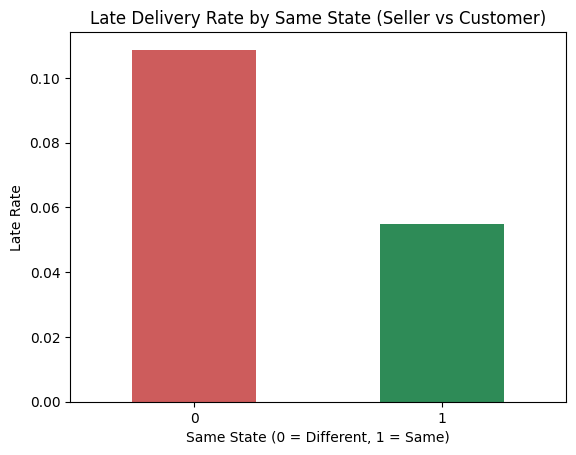

In [3]:
late_by_state = train.groupby("same_state")["is_late"].mean()

late_by_state.plot(kind="bar", color=["indianred", "seagreen"])
plt.title("Late Delivery Rate by Same State (Seller vs Customer)")
plt.xlabel("Same State (0 = Different, 1 = Same)")
plt.ylabel("Late Rate")
plt.xticks(rotation=0)
plt.show()

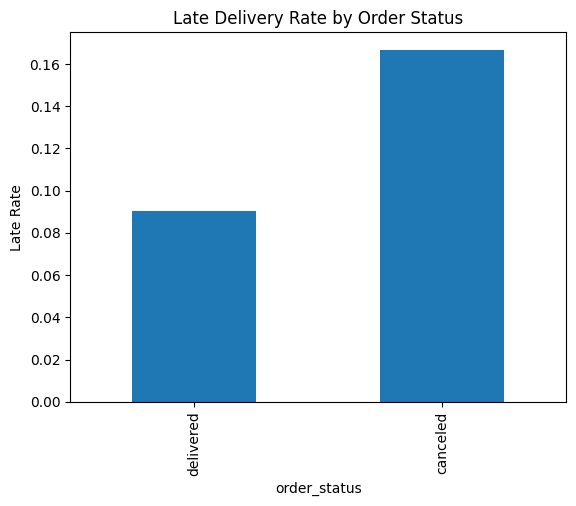

In [4]:
train.groupby("order_status")["is_late"].mean().sort_values().plot(kind="bar")
plt.title("Late Delivery Rate by Order Status")
plt.ylabel("Late Rate")
plt.show()

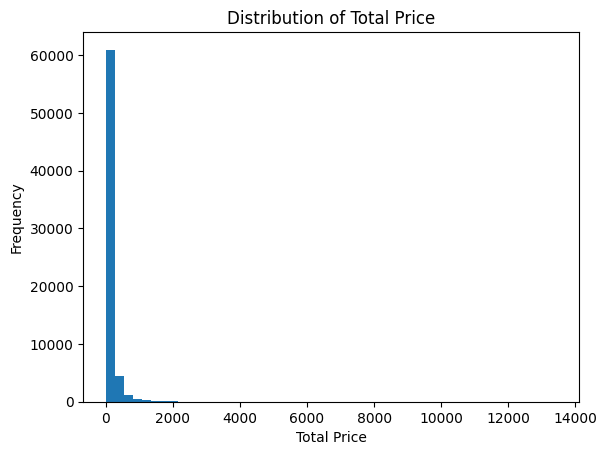

In [5]:
train["total_price"].plot(kind="hist", bins=50)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.show()

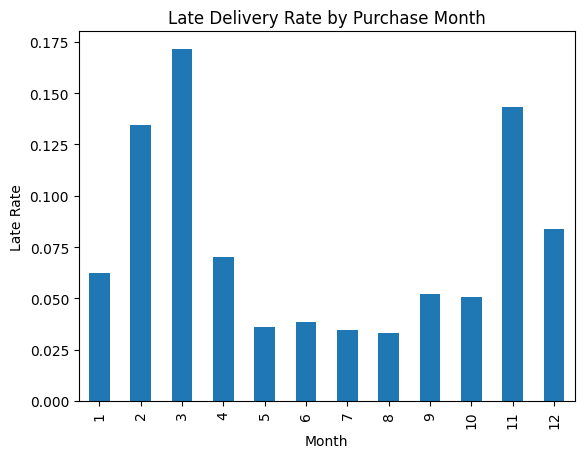

In [6]:
train["order_purchase_timestamp"] = pd.to_datetime(train["order_purchase_timestamp"])
train["purchase_month"] = train["order_purchase_timestamp"].dt.month
train.groupby("purchase_month")["is_late"].mean().plot(kind="bar")
plt.title("Late Delivery Rate by Purchase Month")
plt.ylabel("Late Rate")
plt.xlabel("Month")
plt.show()